# 2D TDoA Positioning for Maritime Search and Rescue
## 1. Problem Formulation
In real-world Maritime Search and Rescue (SAR), locating a vessel using only distances (Trilateration) is difficult because it requires perfectly synchronized clocks between the ship and the stations.

**The Real-World Case:** We use **Time Difference of Arrival (TDoA)**. Instead of measuring absolute distances, we measure the difference in time when an SOS signal reaches different coastal stations. Mathematically, each time difference defines a **hyperbola**. The intersection of these hyperbolas gives the ship's location.

## 2. Assumptions and Constraints
* **Spherical Earth:** We use the **Haversine formula** to account for the Earth's curvature, making the model applicable for long-range maritime rescue.
* **Constant Signal Speed:** Radio waves travel at the speed of light $c \approx 300,000$ km/s.
* **Redundancy:** We use an overdetermined system (more stations than needed) to minimize error using the **Non-linear Least Squares** method.

In [60]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

def haversine(coord1, coord2):
    """
    Calculates the great-circle distance between two points on a sphere (Earth).
    Inputs: coord1, coord2 as (lat, lon) in degrees.
    """
    R = 6371.0  # Earth radius in kilometers
    lat1, lon1 = np.radians(coord1)
    lat2, lon2 = np.radians(coord2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def tdoa_residuals(estimated_pos, stations, tdoa_distances):
    """
    Objective function: calculates the difference between
    expected distance differences and measured ones.
    """
    # Station 0 is our reference point
    d0 = haversine(estimated_pos, stations[0])
    residuals = []

    for i in range(1, len(stations)):
        di = haversine(estimated_pos, stations[i])
        # The difference in distance (observed vs calculated)
        residuals.append((di - d0) - tdoa_distances[i-1])

    return np.array(residuals)

In [61]:
# 1. Define Coastal Stations (Lat, Lon) - Bulgarian Black Sea Coast
# Varna, Burgas, Kavarna, Emine
stations = np.array([
    [43.2047, 27.9100],
    [42.5048, 27.4626],
    [43.4167, 28.3333],
    [42.7015, 27.9000]
])

# 2. Simulated SOS Data
# Real ship location (hidden from the algorithm)
true_ship_pos = np.array([42.9500, 28.5000])

# Calculate true TDoA distances (distance_i - distance_0)
# In reality, these are measured via (Time_i - Time_0) * speed_of_light
tdoa_measured = []
d0_true = haversine(true_ship_pos, stations[0])
for i in range(1, len(stations)):
    tdoa_measured.append(haversine(true_ship_pos, stations[i]) - d0_true)

# 3. Solve using Non-linear Least Squares
initial_guess = np.mean(stations, axis=0)
result = least_squares(tdoa_residuals, initial_guess, args=(stations, tdoa_measured))

# 4. Results
est_pos = result.x
error_km = haversine(true_ship_pos, est_pos)

print(f"True Location: {true_ship_pos}")
print(f"Estimated Location: {est_pos}")
print(f"Total Positioning Error: {error_km:.6f} km")

True Location: [42.95 28.5 ]
Estimated Location: [42.95 28.5 ]
Total Positioning Error: 0.000000 km


## 3. Noise Analysis and Geometry (GDOP)
In a real-world SAR scenario, the Time Difference of Arrival (TDoA) measurements are never perfect due to atmospheric conditions and hardware limitations.

* **Gaussian Noise:** We simulate measurement errors by adding random noise to our TDoA data.
* **GDOP (Geometric Dilution of Precision):** The accuracy of the fix depends heavily on the relative geometry between the ship and the stations. If the stations are nearly collinear (in a line), the error increases significantly.

Distance Error due to noise: 0.54 km


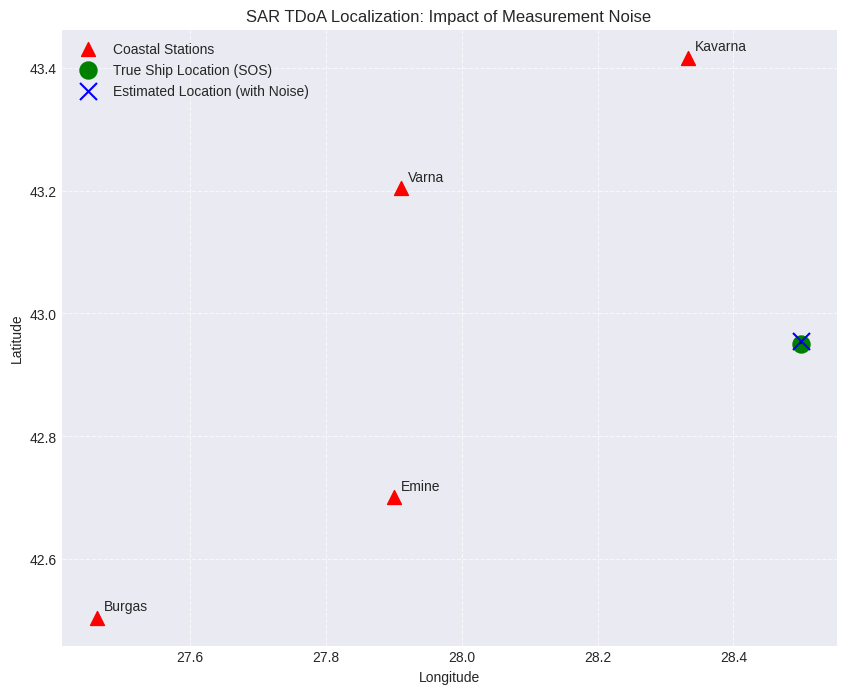

In [62]:
# 1. Add Gaussian Noise to measurements (simulating 500m to 1km error)
noise_sigma = 0.8  # Standard deviation of error in km
noise = np.random.normal(0, noise_sigma, size=len(tdoa_measured))
tdoa_noisy = np.array(tdoa_measured) + noise

# 2. Re-calculate position with noisy data
result_noisy = least_squares(tdoa_residuals, initial_guess, args=(stations, tdoa_noisy))
est_pos_noisy = result_noisy.x

# 3. Visualization
plt.figure(figsize=(10, 8))

# Plot Stations
plt.scatter(stations[:, 1], stations[:, 0], c='red', marker='^', s=100, label='Coastal Stations')
for i, txt in enumerate(['Varna', 'Burgas', 'Kavarna', 'Emine']):
    plt.annotate(txt, (stations[i, 1], stations[i, 0]), xytext=(5, 5), textcoords='offset points')

# Plot True vs Estimated Position
plt.scatter(true_ship_pos[1], true_ship_pos[0], c='green', marker='o', s=150, label='True Ship Location (SOS)')
plt.scatter(est_pos_noisy[1], est_pos_noisy[0], c='blue', marker='x', s=150, label='Estimated Location (with Noise)')

# Draw a line showing the error
plt.plot([true_ship_pos[1], est_pos_noisy[1]], [true_ship_pos[0], est_pos_noisy[0]], 'k--', alpha=0.5)

plt.title('SAR TDoA Localization: Impact of Measurement Noise')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Calculate and print the distance error
final_error = haversine(true_ship_pos, est_pos_noisy)
print(f"Distance Error due to noise: {final_error:.2f} km")
plt.show()